In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


# Data preprocessing

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [6]:
# Age
df["Age"]=2026-df["Year_Birth"]

In [7]:
# Customer joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference=df["Dt_Customer"].max()
df["Tenure_days"]=(reference-df["Dt_Customer"]).dt.days

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [9]:
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [10]:
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [11]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [12]:
df["Education"]=df["Education"].replace({
    "Graduation":"Graduate","Basic":"Undergraduate","2n Cycle":"Undergraduate","Master":"Postgraduate","PhD":"Postgraduate"})

In [13]:
# Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

# Drop Columns

In [14]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [15]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2240 non-null   object 
 1   Income               2240 non-null   float64
 2   Recency              2240 non-null   int64  
 3   NumDealsPurchases    2240 non-null   int64  
 4   NumWebPurchases      2240 non-null   int64  
 5   NumCatalogPurchases  2240 non-null   int64  
 6   NumStorePurchases    2240 non-null   int64  
 7   NumWebVisitsMonth    2240 non-null   int64  
 8   Complain             2240 non-null   int64  
 9   Response             2240 non-null   int64  
 10  Age                  2240 non-null   int64  
 11  Tenure_days          2240 non-null   int64  
 12  Total_spending       2240 non-null   int64  
 13  Total_Children       2240 non-null   int64  
 14  Living_With          2240 non-null   object 
dtypes: float64(1), int64(12), object(2)
me

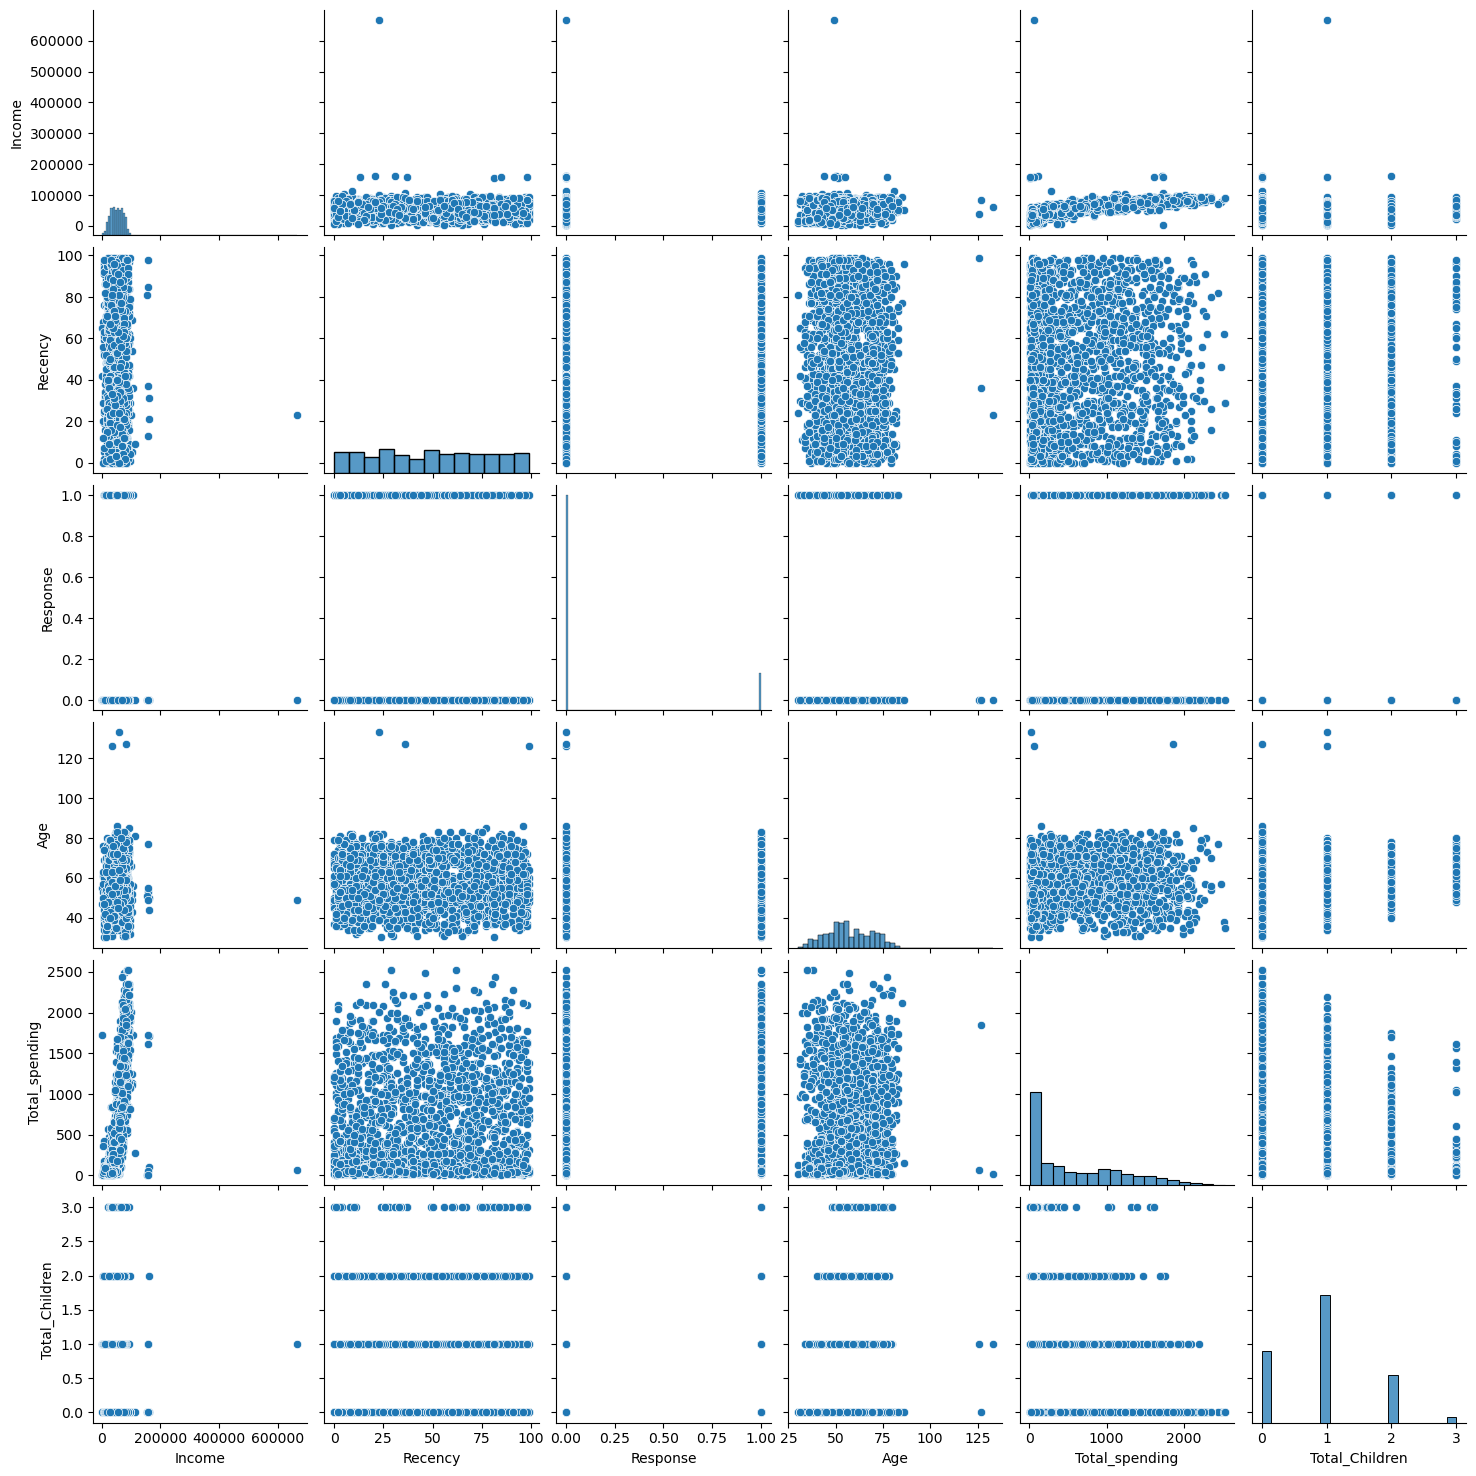

In [16]:
cols = ["Income", "Recency", "Response", "Age", "Total_spending", "Total_Children"]
df_cleaned["Income"] = pd.to_numeric(df_cleaned["Income"], errors="coerce")
# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [17]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

In [18]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

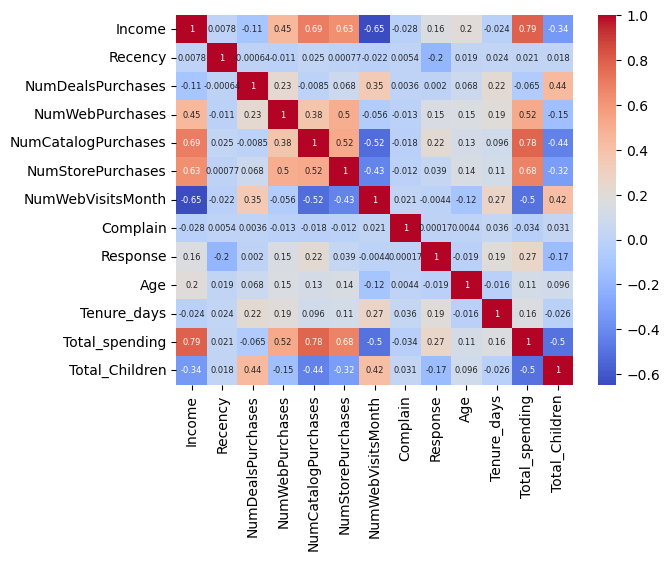

In [19]:
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Encoding

In [20]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [21]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [22]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [23]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

# Scaling

In [24]:
X = df_encoded
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [25]:
# 2D Visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

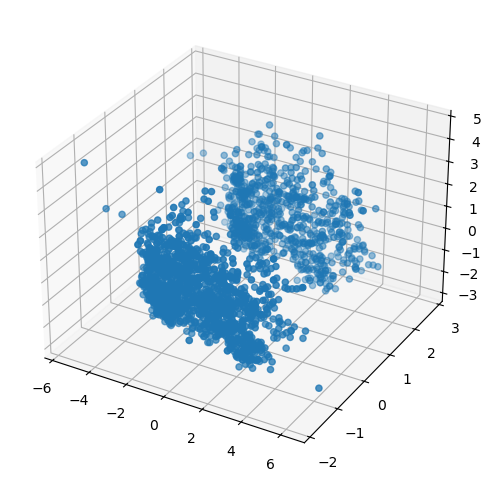

In [26]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

# Analyse K Value

Elbow method

In [27]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range (1,11):
    kmeans=KMeans(n_clusters=k,random_state=4)
    labels=kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [28]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal=knee.elbow

In [29]:
optimal

np.int64(4)

# Silhoutte score

In [30]:
from sklearn.metrics import silhouette_score

In [31]:
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    label=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,label)
    scores.append(score)

C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

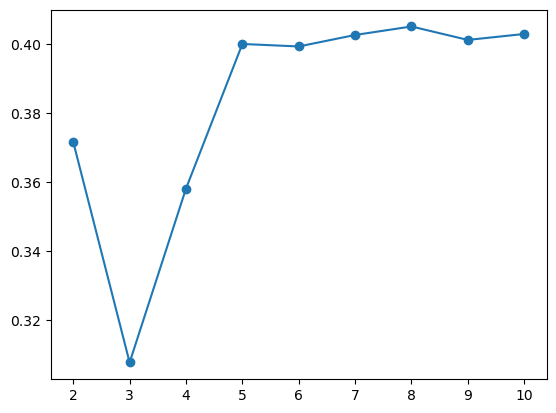

In [32]:
plt.plot(range(2,11),scores,marker='o')


Text(0, 0.5, 'SS')

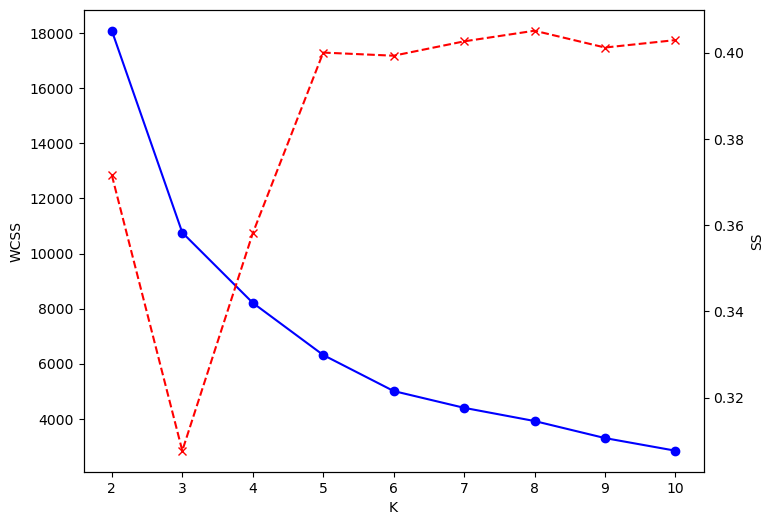

In [33]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering 

In [34]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

C:\Users\banuj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


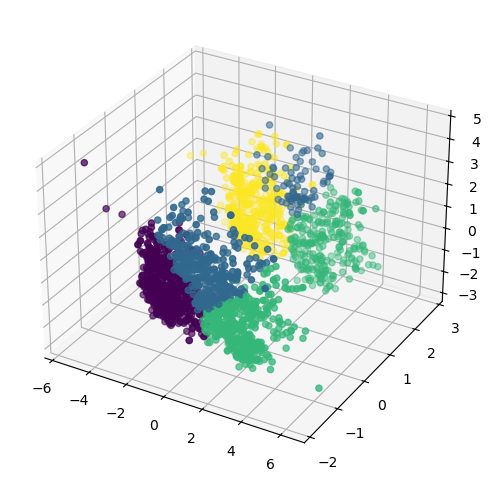

In [35]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [36]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [43]:
# FINAL MODEL - Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels_agg = agg_clf.fit_predict(X_pca)

print("Number of clusters:", len(set(labels_agg)))

Number of clusters: 4


In [47]:
# Cluster Profiling

profile = df_cleaned.copy()

profile["cluster"] = labels_agg

profile.groupby("cluster").mean(numeric_only=True).round(2)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure_days,Total_spending,Total_Children
cluster,,,,,,,,,,,,,
0,39680.58,48.91,2.59,3.15,0.97,4.14,6.31,0.01,0.08,55.67,342.94,221.96,1.24
1,72808.45,49.20,1.96,5.69,5.50,8.66,3.58,0.01,0.17,59.49,369.72,1236.59,0.51
2,36960.14,48.32,2.59,2.71,0.84,3.62,6.66,0.01,0.14,55.69,338.78,165.70,1.27
3,70722.68,50.50,1.86,5.79,5.01,8.43,3.73,0.01,0.32,58.93,376.28,1190.39,0.46


In [48]:
profile["cluster"].value_counts().sort_index()

cluster
0    905
1    534
2    444
3    353
Name: count, dtype: int64

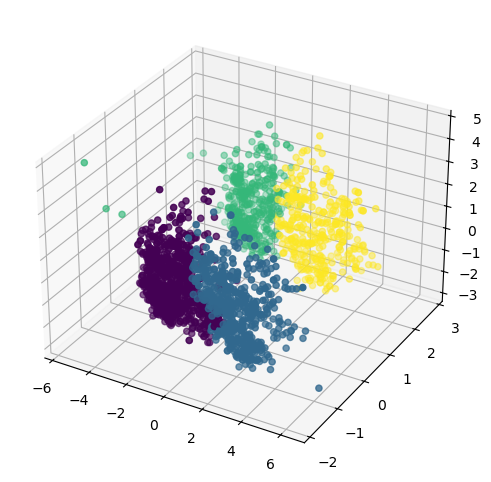

In [46]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

In [39]:
X["cluster"] = labels_agg

<Axes: xlabel='cluster', ylabel='count'>

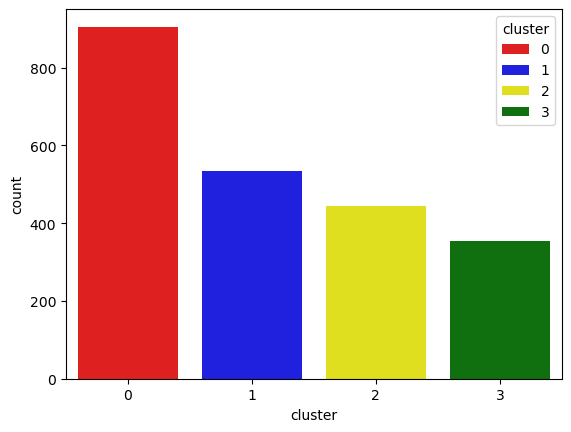

In [40]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

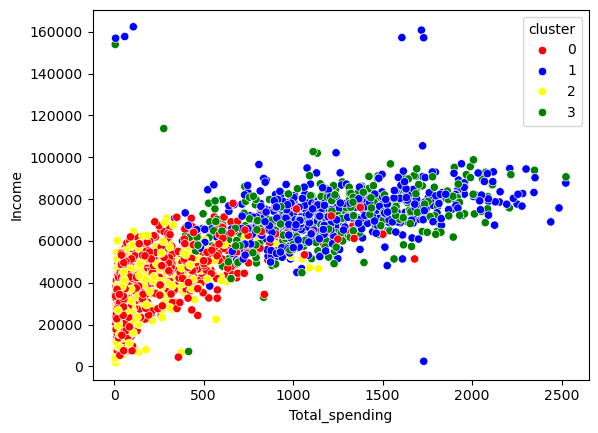

In [41]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [42]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Tenure_days  Total_spending  Total_Children  \
cluster  

In [49]:
# Calculate cluster centers from Agglomerative clusters

import numpy as np

cluster_centers = np.array([
    X_pca[labels_agg == cluster].mean(axis=0)
    for cluster in range(4)
])

cluster_centers

array([[-1.392066  , -0.98461834, -0.08382474],
       [ 2.20243831, -1.14028745, -0.04763476],
       [-1.54761886,  1.91360745,  0.20474866],
       [ 2.18374062,  1.84235521,  0.02943329]])

In [50]:
from sklearn.metrics import accuracy_score

distances = np.linalg.norm(
    X_pca[:, np.newaxis, :] - cluster_centers[np.newaxis, :, :],
    axis=2
)

nearest_cluster = distances.argmin(axis=1)

print("Matching labels:", np.mean(nearest_cluster == labels_agg))

Matching labels: 0.9628801431127012


In [51]:
cluster_centers

array([[-1.392066  , -0.98461834, -0.08382474],
       [ 2.20243831, -1.14028745, -0.04763476],
       [-1.54761886,  1.91360745,  0.20474866],
       [ 2.18374062,  1.84235521,  0.02943329]])

In [52]:
np.mean(nearest_cluster == labels_agg)

np.float64(0.9628801431127012)

In [53]:
import joblib

model_package = {
    "ohe": ohe,
    "scaler": scaler,
    "pca": pca,
    "cluster_centers": cluster_centers,
    "cluster_names": {
        0: "Moderate-Value Customers",
        1: "High-Value Customers",
        2: "Low-Value Customers",
        3: "High-Value Responsive Customers"
    }
}

joblib.dump(model_package, "smartcart_model.pkl")

print("Model saved successfully!")

Model saved successfully!
